##### ARTI 560 - Computer Vision

## Action Recognition - Exercise

### Objective

In this exercise, you will train a deep learning model to recognize three specific human actions using the [UCF11 (YouTube Action) dataset](https://www.crcv.ucf.edu/data/UCF_YouTube_Action.php) and validate the model's real-world performance using external video data.

*[Note: This notebook is based on [this](https://github.com/Sumaya2026/learnopencv/tree/master/Optical-Flow-Estimation-using-Deep-Learning-RAFT) GitHub Repository by LearnOpenCV]*


#### Tasks

- Choose **three classes** from the UCF11 dataset (e.g., Basketball Shooting, Biking, Tennis Swinging, etc.).
- Preprocess the dataset.
- Split the data into training and testing.
- Create and train the model.
- Save the trained model .
    **Important Note**: The final trained model must be saved with a filename that includes your name. This is a mandatory step for the submission.
    ```
    # Example Code
    student_name = "YourName" # Replace with your actual name
    save_path = f"{student_name}_ucf11_model.h5"
    model.save(save_path)
    print(f"Model saved as {save_path}")
    ```
- Validate the model on 3 Youtube videos, each clearly showing one of your three chosen action classes.


Step 1: Import libraries

In [1]:
# Import required libraries
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ConvLSTM2D, MaxPooling3D, TimeDistributed, Dropout, Flatten, Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

Step 2: Set dataset path and classes

In [2]:
# Dataset settings
DATASET_DIR = "UCF11_updated_mpg"

# Select only 3 classes for the exercise
CLASSES_LIST = ["basketball", "biking", "tennis_swing"]

# Video frame settings
IMAGE_HEIGHT, IMAGE_WIDTH = 64, 64
SEQUENCE_LENGTH = 20

Step 3: Check dataset

In [3]:
# Check available classes
print(os.listdir(DATASET_DIR))

['basketball', 'biking', 'diving', 'golf_swing', 'horse_riding', 'soccer_juggling', 'swing', 'tennis_swing', 'trampoline_jumping', 'volleyball_spiking', 'walking']


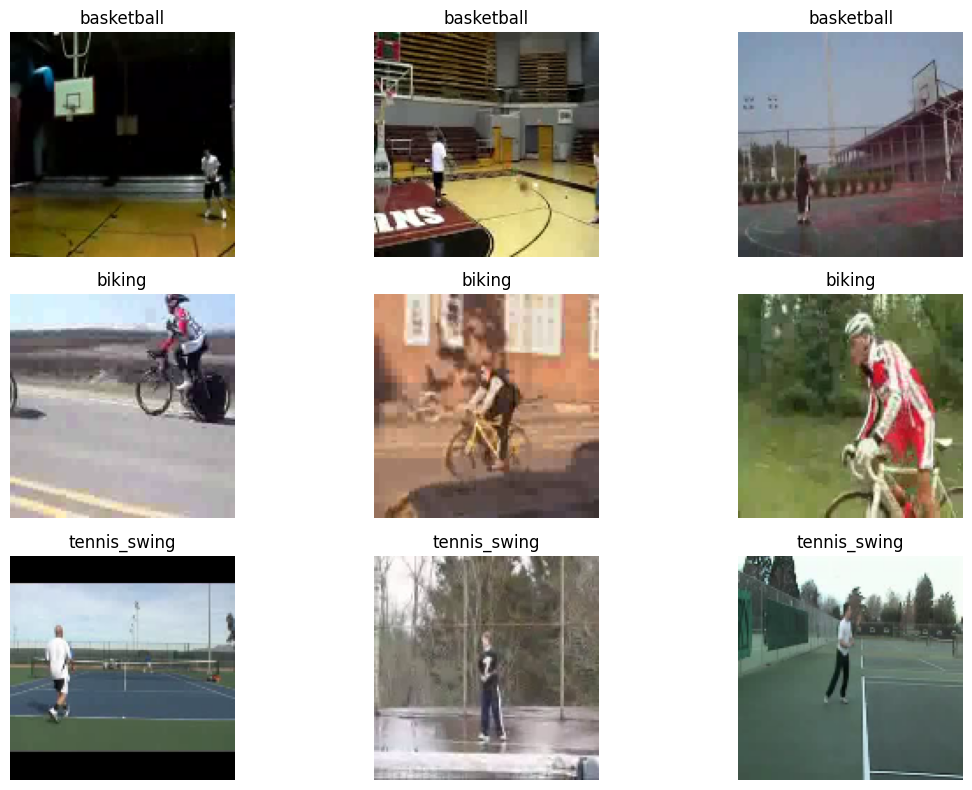

In [46]:
# Visualize sample frames from the selected classes before training
plt.figure(figsize=(12, 8))

counter = 1

for class_name in CLASSES_LIST:
    class_path = os.path.join(DATASET_DIR, class_name)

    video_paths = []

    # Collect all video paths inside the class folder
    for root, dirs, files in os.walk(class_path):
        for file in files:
            if file.endswith((".mpg", ".avi", ".mp4")):
                video_paths.append(os.path.join(root, file))

    # Randomly select 3 videos from each class
    selected_videos = random.sample(video_paths, 3)

    for video_path in selected_videos:
        video_reader = cv2.VideoCapture(video_path)
        success, frame = video_reader.read()
        video_reader.release()

        if success:
            frame = cv2.resize(frame, (128, 128))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            plt.subplot(len(CLASSES_LIST), 3, counter)
            plt.imshow(frame)
            plt.title(class_name)
            plt.axis("off")
            counter += 1

plt.tight_layout()
plt.show()

Step 4: Extract frames from each video

In [4]:
def frames_extraction(video_path):
    # Store extracted frames
    frames_list = []

    # Read the video
    video_reader = cv2.VideoCapture(video_path)

    # Get total number of frames
    video_frames_count = int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))

    # Select frames with equal spacing
    skip_frames_window = max(int(video_frames_count / SEQUENCE_LENGTH), 1)

    for frame_counter in range(SEQUENCE_LENGTH):
        # Move to the selected frame
        video_reader.set(cv2.CAP_PROP_POS_FRAMES, frame_counter * skip_frames_window)

        # Read the frame
        success, frame = video_reader.read()

        if not success:
            break

        # Resize and normalize the frame
        resized_frame = cv2.resize(frame, (IMAGE_WIDTH, IMAGE_HEIGHT))
        normalized_frame = resized_frame / 255.0

        frames_list.append(normalized_frame)

    video_reader.release()

    return frames_list

Step 5: Create dataset

In [31]:
def create_dataset():
    features = []
    labels = []

    for class_index, class_name in enumerate(CLASSES_LIST):
        print(f"Extracting data from class: {class_name}")

        class_path = os.path.join(DATASET_DIR, class_name)

        for root, dirs, files in os.walk(class_path):
            for video_name in files:
                if video_name.endswith((".mpg", ".avi", ".mp4")):
                    video_path = os.path.join(root, video_name)

                    frames = frames_extraction(video_path)

                    if len(frames) == SEQUENCE_LENGTH:
                        features.append(frames)
                        labels.append(class_index)

    return np.asarray(features), np.array(labels)

Step 6: Run dataset creation

In [34]:
features, labels = create_dataset()

print("Features:", features.shape)
print("Labels:", labels.shape)
print("Unique labels:", np.unique(labels))

Extracting data from class: basketball
Extracting data from class: biking
Extracting data from class: tennis_swing
Features: (450, 20, 64, 64, 3)
Labels: (450,)
Unique labels: [0 1 2]


In [35]:
one_hot_encoded_labels = to_categorical(labels, num_classes=len(CLASSES_LIST))

print("One hot labels:", one_hot_encoded_labels.shape)

One hot labels: (450, 3)


In [32]:
features, labels = create_dataset()
print(features.shape)

Extracting data from class: basketball
Extracting data from class: biking
Extracting data from class: tennis_swing
(450, 20, 64, 64, 3)


Step 7: Split data

In [36]:
features_train, features_test, labels_train, labels_test = train_test_split(
    features,
    one_hot_encoded_labels,
    test_size=0.25,
    shuffle=True,
    random_state=42
)

Step 8: Build the model

In [37]:
model = Sequential()

model.add(ConvLSTM2D(
    filters=4,
    kernel_size=(3, 3),
    activation='tanh',
    data_format="channels_last",
    recurrent_dropout=0.2,
    return_sequences=True,
    input_shape=(SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3)
))

model.add(MaxPooling3D(pool_size=(1, 2, 2), padding='same'))
model.add(TimeDistributed(Dropout(0.2)))

model.add(Flatten())

model.add(Dense(len(CLASSES_LIST), activation="softmax"))

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d_6 (ConvLSTM2D)      │ (None, 20, 62, 62, 4)  │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_6 (MaxPooling3D)  │ (None, 20, 31, 31, 4)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 20, 31, 31, 4)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 76880)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │       230,643 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 231,667 (904.95 KB)

 Trainable params: 231,667 (904.95 KB)

 Non-trainable params: 0 (0.00 B)

Step 9: Compile and train

In [39]:
early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model.compile(
    loss='categorical_crossentropy',
    optimizer='Adam',
    metrics=["accuracy"]
)

history = model.fit(
    features_train,
    labels_train,
    epochs=20,
    batch_size=4,
    validation_split=0.2,
    callbacks=[early_stopping_callback]
)

Epoch 1/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - accuracy: 0.9182 - loss: 0.2393 - val_accuracy: 0.7059 - val_loss: 1.5620
Epoch 2/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - accuracy: 0.9777 - loss: 0.0573 - val_accuracy: 0.8088 - val_loss: 0.8088
Epoch 3/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - accuracy: 1.0000 - loss: 0.0085 - val_accuracy: 0.7353 - val_loss: 1.0484
Epoch 4/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - accuracy: 1.0000 - loss: 0.0059 - val_accuracy: 0.7353 - val_loss: 1.1422
Epoch 5/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - accuracy: 1.0000 - loss: 0.0037 - val_accuracy: 0.7353 - val_loss: 1.2423
Epoch 6/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 0.7353 - val_loss: 1.2883
Epoch 7/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.7353 - val_loss: 1.2662


Step 10: Evaluate the model

In [40]:
model_evaluation_history = model.evaluate(features_test, labels_test)

print("Test Loss:", model_evaluation_history[0])
print("Test Accuracy:", model_evaluation_history[1])

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.8230 - loss: 0.9795
Test Loss: 0.9794901609420776
Test Accuracy: 0.8230088353157043


In [ ]:
student_name = "Fatimah Alageel"
model_file_name = f"{student_name}_ucf11_action_recognition_model.h5"

model.save(model_file_name)

print("Model saved as:", model_file_name)

Model saved as: Fatimah Alageel_ucf11_action_recognition_model.h5


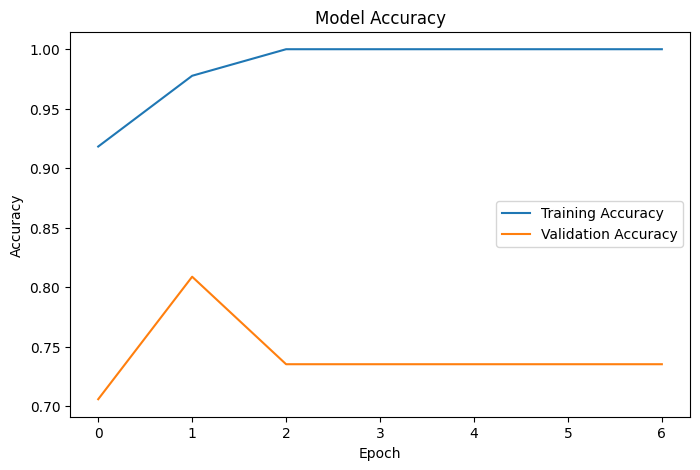

In [42]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

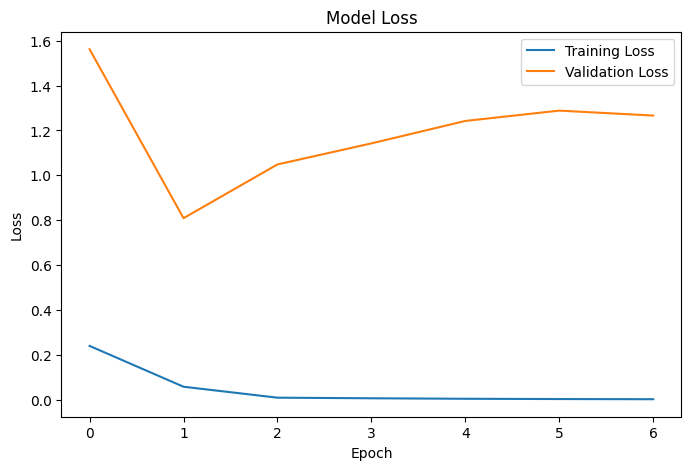

In [45]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

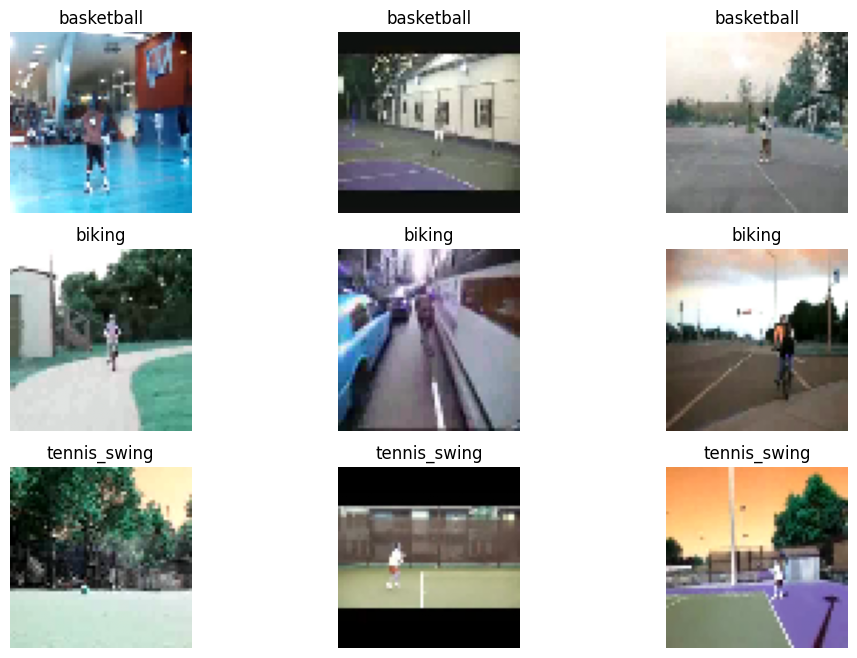

In [44]:
plt.figure(figsize=(12, 8))

counter = 1

for class_name in CLASSES_LIST:
    class_path = os.path.join(DATASET_DIR, class_name)

    video_paths = []
    for root, dirs, files in os.walk(class_path):
        for file in files:
            if file.endswith((".mpg", ".avi", ".mp4")):
                video_paths.append(os.path.join(root, file))

    for video_path in random.sample(video_paths, 3):
        frames = frames_extraction(video_path)

        plt.subplot(len(CLASSES_LIST), 3, counter)
        plt.imshow(frames[0])
        plt.title(class_name)
        plt.axis("off")
        counter += 1

plt.show()

In this lab exercise, we implemented a video action recognition system using the UCF11 dataset. Videos were converted into sequences of frames, which were then used to train a ConvLSTM model. The model learns both spatial and temporal features, enabling it to classify human actions such as basketball, biking, and tennis swing.